In [1]:
# Cell 1
import os
import re
import tarfile
import zipfile
import sqlite3
from pathlib import Path
from getpass import getpass
from urllib.parse import urljoin

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup
import xml.etree.ElementTree as ET

In [2]:
# Cell 2
ROOT = Path("./hc-3-linear")
ROOT.mkdir(exist_ok=True)

BASE = "https://portal.nersc.gov/project/crcns/download/hc-3"
META_ZIP_URL = "https://crcns.org/files/data/hc3/crcns-hc3-metadata-tables.zip"

BEHAVIOR = "linear"
# REGION_FILTER = ["CA1", "EC2", "EC3", "EC4", "EC5"]   
REGION_FILTER = None  
SELECT_ROW = 0
CANDIDATE_LIMIT = 200

WHL_FS = 39.06
POS_BINS = 80
VEL_SMOOTH = 5
VEL_THRESH = 0.02
FORCE_REDOWNLOAD = False

In [3]:
# Cell 3
def login_crcns(url, username, password):
    s = requests.Session()
    r = s.get(url, timeout=60)
    r.raise_for_status()
    soup = BeautifulSoup(r.text, "html.parser")
    form = soup.find("form")
    if form is None:
        return s

    action = urljoin(r.url, form.get("action") or r.url)
    payload = {}
    user_key = None
    pass_key = None

    for inp in form.find_all("input"):
        name = inp.get("name")
        if not name:
            continue
        typ = (inp.get("type") or "text").lower()
        val = inp.get("value", "")
        if typ in {"hidden", "submit"}:
            payload[name] = val
        lname = name.lower()
        if typ == "password" or "pass" in lname:
            pass_key = name
        elif typ in {"text", "email"} or "user" in lname or "login" in lname:
            if user_key is None:
                user_key = name

    payload[user_key or "username"] = username
    payload[pass_key or "password"] = password

    r2 = s.post(action, data=payload, allow_redirects=True, timeout=60)
    r2.raise_for_status()
    return s


def download_public(url, out_path, force=False):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and out_path.stat().st_size > 0 and not force:
        return out_path
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    out_path.write_bytes(r.content)
    return out_path


def download_auth(session, url, out_path, force=False):
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    if out_path.exists() and out_path.stat().st_size > 0 and not force:
        return out_path

    tmp = out_path.with_suffix(out_path.suffix + ".part")
    with session.get(url, stream=True, timeout=120) as r:
        r.raise_for_status()
        with open(tmp, "wb") as f:
            for chunk in r.iter_content(chunk_size=1024 * 1024):
                if chunk:
                    f.write(chunk)
    os.replace(tmp, out_path)
    return out_path


def extract_zip(zip_path, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(out_dir)


def extract_tar_gz(tar_path, out_dir):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    with tarfile.open(tar_path, "r:gz") as tf:
        tf.extractall(out_dir)


def find_one(root, pattern):
    hits = list(Path(root).rglob(pattern))
    return hits[0] if len(hits) > 0 else None


def read_xml_sample_rate(xml_path):
    root = ET.parse(xml_path).getroot()
    nodes = root.findall(".//samplingRate")
    for node in nodes:
        txt = (node.text or "").strip()
        if txt:
            return float(txt)
    return 20000.0


def read_whl(whl_path):
    arr = np.loadtxt(whl_path)
    if arr.ndim == 1:
        arr = arr[:, None]

    if arr.shape[1] >= 4:
        xy1 = arr[:, 0:2].astype(float)
        xy2 = arr[:, 2:4].astype(float)

        valid1 = (xy1[:, 0] >= 0) & (xy1[:, 1] >= 0)
        valid2 = (xy2[:, 0] >= 0) & (xy2[:, 1] >= 0)

        x = np.full(arr.shape[0], np.nan)
        y = np.full(arr.shape[0], np.nan)

        both = valid1 & valid2
        x[both] = 0.5 * (xy1[both, 0] + xy2[both, 0])
        y[both] = 0.5 * (xy1[both, 1] + xy2[both, 1])

        only1 = valid1 & (~valid2)
        x[only1] = xy1[only1, 0]
        y[only1] = xy1[only1, 1]

        only2 = valid2 & (~valid1)
        x[only2] = xy2[only2, 0]
        y[only2] = xy2[only2, 1]

        xy = np.column_stack([x, y])
    else:
        xy = arr[:, :2].astype(float)

    valid = np.isfinite(xy[:, 0]) & np.isfinite(xy[:, 1]) & (xy[:, 0] >= 0) & (xy[:, 1] >= 0)
    xy[~valid] = np.nan
    return xy, valid


def linearize_track(xy, valid):
    pts = xy[valid]
    mu = pts.mean(axis=0, keepdims=True)
    u, s, vh = np.linalg.svd(pts - mu, full_matrices=False)
    pc1 = vh[0]
    if abs(pc1[0]) < abs(pc1[1]):
        pc1 = -pc1 if pc1[1] < 0 else pc1
    else:
        pc1 = -pc1 if pc1[0] < 0 else pc1

    z = (xy - mu) @ pc1
    zmin = np.nanmin(z[valid])
    zmax = np.nanmax(z[valid])
    p = (z - zmin) / (zmax - zmin + 1e-12)
    return p


def read_int_vec(path):
    x = np.loadtxt(path, dtype=np.int64)
    return np.atleast_1d(x)


def build_unit_spike_times(session_root, unit_meta, sample_rate_hz):
    unit_meta = unit_meta.copy()
    unit_meta["spike_times_sec"] = [np.array([], dtype=float) for _ in range(len(unit_meta))]

    for ele in sorted(unit_meta["ele"].unique()):
        clu_path = find_one(session_root, f"*.clu.{int(ele)}")
        res_path = find_one(session_root, f"*.res.{int(ele)}")
        if clu_path is None or res_path is None:
            continue

        clu_raw = read_int_vec(clu_path)
        res = read_int_vec(res_path)

        clu = clu_raw[1:]
        if len(clu) != len(res):
            continue

        idxs = unit_meta.index[unit_meta["ele"] == ele].tolist()
        for idx in idxs:
            clu_id = int(unit_meta.loc[idx, "clu"])
            keep = (clu == clu_id)
            unit_meta.at[idx, "spike_times_sec"] = res[keep].astype(float) / sample_rate_hz

    return unit_meta


def smooth_1d(x, k):
    if k <= 1:
        return x.copy()
    w = np.ones(k, dtype=float) / k
    return np.convolve(x, w, mode="same")

In [4]:
# Cell 4
docs_dir = ROOT / "docs"
meta_dir = ROOT / "meta"

zip_path = download_public(META_ZIP_URL, docs_dir / "crcns-hc3-metadata-tables.zip", force=FORCE_REDOWNLOAD)
extract_zip(zip_path, meta_dir)

db_path = list(meta_dir.rglob("hc3-tables.db"))[0]
con = sqlite3.connect(db_path)

q = """
WITH sess AS (
    SELECT
        s.id,
        s.topdir,
        s.session,
        s.behavior,
        s.familiarity,
        s.duration,
        f.video_type
    FROM session s
    JOIN file f
      ON s.topdir = f.topdir AND s.session = f.session
    WHERE s.behavior = ?
),
cell_counts AS (
    SELECT
        c.topdir,
        SUM(CASE WHEN c.region = 'CA1' THEN 1 ELSE 0 END) AS n_ca1,
        SUM(CASE WHEN c.region LIKE 'EC%' THEN 1 ELSE 0 END) AS n_ec
    FROM cell c
    GROUP BY c.topdir
)
SELECT
    sess.id,
    sess.topdir,
    sess.session,
    sess.familiarity,
    sess.duration,
    sess.video_type,
    COALESCE(cell_counts.n_ca1, 0) AS n_ca1,
    COALESCE(cell_counts.n_ec, 0) AS n_ec
FROM sess
LEFT JOIN cell_counts
  ON cell_counts.topdir = sess.topdir
WHERE sess.video_type != '-'
ORDER BY n_ca1 DESC, sess.duration DESC
LIMIT ?
"""

cand_df = pd.read_sql_query(q, con, params=[BEHAVIOR, CANDIDATE_LIMIT])
display(cand_df)
assert len(cand_df) > 0, "No candidate sessions found"

,id,topdir,session,familiarity,duration,video_type,n_ca1,n_ec
0,557,ec013.40,ec013.719,10,1202.176,mpg,53,39
1,45,ec012ec.13,ec012ec.240,10,637.500,m1v,0,27
2,126,ec012ec.18,ec012ec.375,10,631.200,m1v,0,24
3,212,ec012ec.24,ec012ec.504,10,614.800,m1v,0,14
4,188,ec012ec.22,ec012ec.467,10,576.300,m1v,0,19
5,111,ec012ec.17,ec012ec.357,10,565.300,m1v,0,32
6,63,ec012ec.14,ec012ec.269,10,507.400,m1v,0,22
7,125,ec012ec.18,ec012ec.374,10,505.100,m1v,0,24
8,186,ec012ec.22,ec012ec.465,10,488.300,m1v,0,19
9,211,ec012ec.24,ec012ec.503,10,474.100,m1v,0,14


In [5]:
# New Cell 4.5
# scan top candidate linear sessions and count active units after loading
SCAN_LIMIT = len(cand_df)
scan_rows = []

username = input("CRCNS username: ").strip()
password = getpass("CRCNS password: ")
http = login_crcns(BASE, username, password)

for cand_idx, row in cand_df.head(SCAN_LIMIT).iterrows():
    topdir = row["topdir"]
    session_name = row["session"]

    tar_url = f"{BASE}/{topdir}/{session_name}.tar.gz"
    tar_path = ROOT / "raw" / topdir / f"{session_name}.tar.gz"
    download_auth(http, tar_url, tar_path, force=False)

    sess_dir = ROOT / "sessions" / session_name
    if not sess_dir.exists():
        extract_tar_gz(tar_path, sess_dir)

    xml_path = find_one(sess_dir, "*.xml")
    whl_path = find_one(sess_dir, "*.whl")

    if xml_path is None or whl_path is None:
        scan_rows.append({
            "cand_idx": cand_idx,
            "topdir": topdir,
            "session": session_name,
            "metadata_units": np.nan,
            "active_units": np.nan,
            "has_xml": xml_path is not None,
            "has_whl": whl_path is not None,
        })
        continue

    if REGION_FILTER is None:
        q_units = """
        SELECT DISTINCT ele, clu, region
        FROM cell
        WHERE topdir = ?
        ORDER BY ele, clu
        """
        unit_meta = pd.read_sql_query(q_units, con, params=[topdir])
    else:
        region_placeholders = ",".join(["?"] * len(REGION_FILTER))
        q_units = f"""
        SELECT DISTINCT ele, clu, region
        FROM cell
        WHERE topdir = ?
          AND region IN ({region_placeholders})
        ORDER BY ele, clu
        """
        unit_meta = pd.read_sql_query(q_units, con, params=[topdir] + REGION_FILTER)

    sample_rate_hz = read_xml_sample_rate(xml_path)
    unit_meta = build_unit_spike_times(sess_dir, unit_meta, sample_rate_hz)
    unit_meta["spike_times_sec"] = unit_meta["spike_times_sec"].map(
        lambda x: np.asarray(np.atleast_1d(x), dtype=float)
    )
    unit_meta["n_spikes"] = unit_meta["spike_times_sec"].map(lambda x: int(np.size(x)))
    active_units = int((unit_meta["n_spikes"] > 0).sum())

    scan_rows.append({
        "cand_idx": cand_idx,
        "topdir": topdir,
        "session": session_name,
        "metadata_units": int(len(unit_meta)),
        "active_units": active_units,
        "has_xml": True,
        "has_whl": True,
    })

scan_df = pd.DataFrame(scan_rows).sort_values(
    ["active_units", "metadata_units"], ascending=False
).reset_index(drop=True)

display(scan_df)

CRCNS username:  wgcdsb
CRCNS password:  ········


,cand_idx,topdir,session,metadata_units,active_units,has_xml,has_whl
0,0,ec013.40,ec013.719,92,62,True,True
1,5,ec012ec.17,ec012ec.357,32,18,True,True
2,11,ec012ec.17,ec012ec.356,32,17,True,True
3,1,ec012ec.13,ec012ec.240,27,16,True,True
4,10,ec012ec.13,ec012ec.239,27,16,True,True
5,6,ec012ec.14,ec012ec.269,22,14,True,True
6,13,ec012ec.14,ec012ec.270,22,14,True,True
7,4,ec012ec.22,ec012ec.467,19,13,True,True
8,8,ec012ec.22,ec012ec.465,19,13,True,True
9,12,ec012ec.22,ec012ec.466,19,13,True,True


In [6]:
SELECT_ROW = int(scan_df.iloc[0]["cand_idx"])

In [7]:
# Cell 5
row = cand_df.iloc[SELECT_ROW]
topdir = row["topdir"]
session_name = row["session"]
familiarity = int(row["familiarity"])

print("selected:", topdir, session_name, "familiarity=", familiarity)

tar_url = f"{BASE}/{topdir}/{session_name}.tar.gz"
tar_path = ROOT / "raw" / topdir / f"{session_name}.tar.gz"
download_auth(http, tar_url, tar_path, force=FORCE_REDOWNLOAD)

sess_dir = ROOT / "sessions" / session_name
if FORCE_REDOWNLOAD and sess_dir.exists():
    import shutil
    shutil.rmtree(sess_dir)
if not sess_dir.exists():
    extract_tar_gz(tar_path, sess_dir)

xml_path = find_one(sess_dir, "*.xml")
whl_path = find_one(sess_dir, "*.whl")

assert xml_path is not None, "missing .xml"
assert whl_path is not None, "missing .whl"
print("xml:", xml_path.name)
print("whl:", whl_path.name)

selected: ec013.40 ec013.719 familiarity= 10
xml: ec013.719.xml
whl: ec013.719.whl


In [8]:
# # Cell 6
# if REGION_FILTER is None:
#     q_units = """
#     SELECT DISTINCT ele, clu, region
#     FROM cell
#     WHERE topdir = ?
#     ORDER BY ele, clu
#     """
#     unit_meta = pd.read_sql_query(q_units, con, params=[topdir])
# else:
#     region_placeholders = ",".join(["?"] * len(REGION_FILTER))
#     q_units = f"""
#     SELECT DISTINCT ele, clu, region
#     FROM cell
#     WHERE topdir = ?
#       AND region IN ({region_placeholders})
#     ORDER BY ele, clu
#     """
#     unit_meta = pd.read_sql_query(q_units, con, params=[topdir] + REGION_FILTER)

# display(unit_meta.head())
# print("n_units in metadata =", len(unit_meta))
# assert len(unit_meta) > 0, "No units for chosen region filter"

# sample_rate_hz = read_xml_sample_rate(xml_path)
# unit_meta = build_unit_spike_times(sess_dir, unit_meta, sample_rate_hz)

# unit_meta["spike_times_sec"] = unit_meta["spike_times_sec"].map(
#     lambda x: np.asarray(np.atleast_1d(x), dtype=float)
# )

# unit_meta["n_spikes"] = unit_meta["spike_times_sec"].map(
#     lambda x: int(np.size(x))
# )

# unit_meta = unit_meta[unit_meta["n_spikes"] > 0].reset_index(drop=True)

# display(unit_meta.head())
# print("n_units with spikes =", len(unit_meta))

# Cell 6
if REGION_FILTER is None:
    q_units = """
    SELECT DISTINCT ele, clu, region
    FROM cell
    WHERE topdir = ?
    ORDER BY ele, clu
    """
    unit_meta = pd.read_sql_query(q_units, con, params=[topdir])
else:
    region_placeholders = ",".join(["?"] * len(REGION_FILTER))
    q_units = f"""
    SELECT DISTINCT ele, clu, region
    FROM cell
    WHERE topdir = ?
      AND region IN ({region_placeholders})
    ORDER BY ele, clu
    """
    unit_meta = pd.read_sql_query(q_units, con, params=[topdir] + REGION_FILTER)

print("metadata units by region:")
print(unit_meta["region"].value_counts(dropna=False).sort_index())
display(unit_meta.head())
print("n_units in metadata =", len(unit_meta))
assert len(unit_meta) > 0, "No units for chosen region filter"

sample_rate_hz = read_xml_sample_rate(xml_path)
unit_meta = build_unit_spike_times(sess_dir, unit_meta, sample_rate_hz)

unit_meta["spike_times_sec"] = unit_meta["spike_times_sec"].map(
    lambda x: np.asarray(np.atleast_1d(x), dtype=float)
)
unit_meta["n_spikes"] = unit_meta["spike_times_sec"].map(
    lambda x: int(np.size(x))
)

unit_meta = unit_meta[unit_meta["n_spikes"] > 0].reset_index(drop=True)

print("\nactive units by region:")
print(unit_meta["region"].value_counts(dropna=False).sort_index())
display(unit_meta.head())
print("n_units with spikes =", len(unit_meta))

metadata units by region:
region
CA1    53
EC2    12
EC3    17
EC5    10
Name: count, dtype: int64


,ele,clu,region
0,1,2,EC2
1,1,3,EC2
2,1,4,EC2
3,1,5,EC2
4,1,6,EC2


n_units in metadata = 92

active units by region:
region
CA1    37
EC2     9
EC3     7
EC5     9
Name: count, dtype: int64


,ele,clu,region,spike_times_sec,n_spikes
0,1,3,EC2,"[457.99975, 590.2591, 622.364, 648.47875, 678....",16
1,1,4,EC2,"[0.01055, 0.1265, 0.26075, 1.4499, 1.54655, 2....",1343
2,1,5,EC2,"[2.21555, 2.7744, 5.81855, 6.32535, 7.32175, 8...",394
3,1,6,EC2,"[1.3697, 3.5065, 3.9998, 4.19495, 4.2781, 4.98...",714
4,1,7,EC2,"[1.988, 2.08075, 2.7, 3.71275, 4.0329, 4.0878,...",3122


n_units with spikes = 62


In [9]:
# # Cell 7
# xy, valid = read_whl(whl_path)
# p = linearize_track(xy, valid)

# n = len(p)
# t_edges = np.arange(n + 1, dtype=float) / WHL_FS
# t_mid = 0.5 * (t_edges[:-1] + t_edges[1:])

# p_smooth = smooth_1d(np.where(valid, p, np.nan), 5)
# p_smooth = pd.Series(p_smooth).interpolate(limit_direction="both").to_numpy()

# v = np.diff(p_smooth, prepend=p_smooth[0]) * WHL_FS
# v_smooth = smooth_1d(v, VEL_SMOOTH)
# speed = np.abs(v_smooth)
# direction = np.sign(v_smooth).astype(int)
# direction[speed < VEL_THRESH] = 0
# turning = (direction == 0)

# time_norm = (t_mid - t_mid.min()) / (t_mid.max() - t_mid.min() + 1e-12)

# X = np.zeros((n, len(unit_meta)), dtype=np.int16)
# for j, spk_t in enumerate(unit_meta["spike_times_sec"].tolist()):
#     X[:, j] = np.histogram(spk_t, bins=t_edges)[0]

# cov_df = pd.DataFrame({
#     "time": t_mid,
#     "time_norm": time_norm,
#     "pos_smooth": p_smooth,
#     "direction": direction,
#     "turning": turning,
# })

# keep = valid & np.isfinite(p_smooth) & (~turning)
# X = X[keep]
# cov_df = cov_df.loc[keep].reset_index(drop=True)

# cov_df["direction01"] = (cov_df["direction"] > 0).astype(int)

# print("X shape =", X.shape, "   # (T, d)")
# print("cov_df shape =", cov_df.shape)
# display(cov_df.head())

# Cell 7
xy, valid = read_whl(whl_path)
p = linearize_track(xy, valid)

n = len(p)
t_edges = np.arange(n + 1, dtype=float) / WHL_FS
t_mid = 0.5 * (t_edges[:-1] + t_edges[1:])

# raw 2D position
x_raw = xy[:, 0].astype(float)
y_raw = xy[:, 1].astype(float)

# normalized raw 2D position, using valid WHL samples only
x_min, x_max = np.nanmin(x_raw[valid]), np.nanmax(x_raw[valid])
y_min, y_max = np.nanmin(y_raw[valid]), np.nanmax(y_raw[valid])

x_norm = (x_raw - x_min) / (x_max - x_min + 1e-12)
y_norm = (y_raw - y_min) / (y_max - y_min + 1e-12)

p_smooth = smooth_1d(np.where(valid, p, np.nan), 5)
p_smooth = pd.Series(p_smooth).interpolate(limit_direction="both").to_numpy()

v = np.diff(p_smooth, prepend=p_smooth[0]) * WHL_FS
v_smooth = smooth_1d(v, VEL_SMOOTH)
speed = np.abs(v_smooth)
direction = np.sign(v_smooth).astype(int)
direction[speed < VEL_THRESH] = 0
turning = (direction == 0)

time_norm = (t_mid - t_mid.min()) / (t_mid.max() - t_mid.min() + 1e-12)

X = np.zeros((n, len(unit_meta)), dtype=np.int16)
for j, spk_t in enumerate(unit_meta["spike_times_sec"].tolist()):
    X[:, j] = np.histogram(spk_t, bins=t_edges)[0]

cov_df = pd.DataFrame({
    "time": t_mid,
    "time_norm": time_norm,
    "pos_smooth": p_smooth,
    "direction": direction,
    "turning": turning,
    "x_raw": x_raw,
    "y_raw": y_raw,
    "x_norm": x_norm,
    "y_norm": y_norm,
})

keep = (
    valid
    & np.isfinite(p_smooth)
    & np.isfinite(x_raw)
    & np.isfinite(y_raw)
    & (~turning)
)

X = X[keep]
cov_df = cov_df.loc[keep].reset_index(drop=True)

cov_df["direction01"] = (cov_df["direction"] > 0).astype(int)

print("X shape =", X.shape, "   # (T, d)")
print("cov_df shape =", cov_df.shape)
display(cov_df.head())

X shape = (29239, 62)    # (T, d)
cov_df shape = (29239, 10)


,time,time_norm,pos_smooth,direction,turning,x_raw,y_raw,x_norm,y_norm,direction01
0,26.689708,0.022189,0.818763,1,False,226.48070,42.096985,0.753630,0.154904,1
1,26.715310,0.022210,0.819754,1,False,226.85940,42.298020,0.755322,0.155905,1
2,26.740911,0.022232,0.820287,1,False,227.26300,42.526510,0.757124,0.157043,1
3,26.766513,0.022253,0.821081,1,False,227.65765,42.792910,0.758887,0.158369,1
4,26.792115,0.022274,0.821957,1,False,228.23310,42.986125,0.761457,0.159331,1


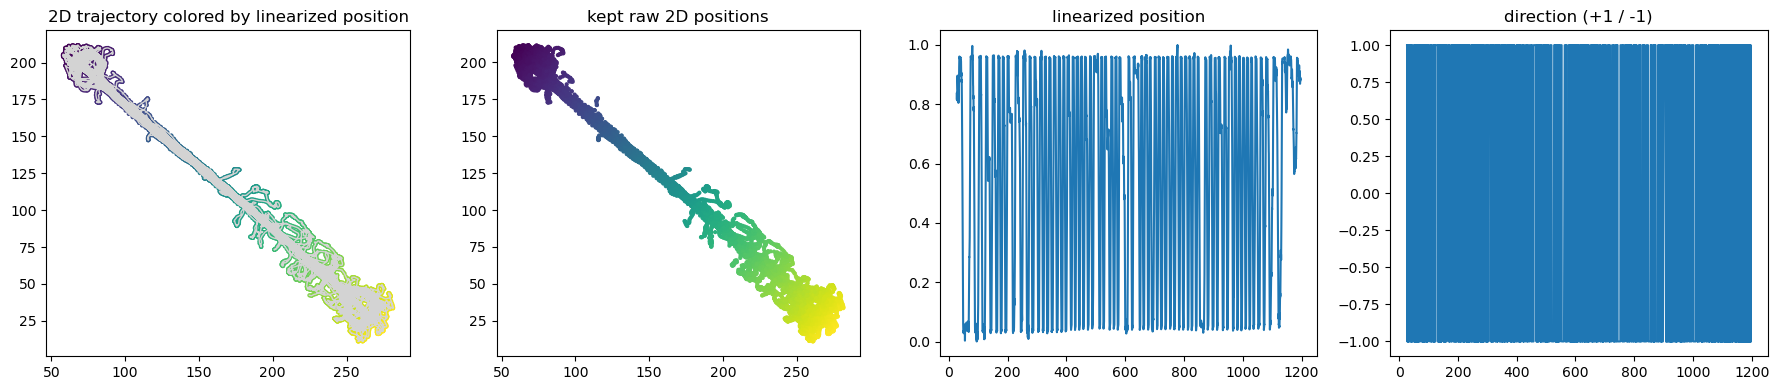

In [10]:
# Cell 8
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

axes[0].plot(xy[:, 0], xy[:, 1], color="lightgray", linewidth=1)
axes[0].scatter(xy[valid, 0], xy[valid, 1], c=p[valid], s=4)
axes[0].set_title("2D trajectory colored by linearized position")
axes[0].set_aspect("equal")

axes[1].scatter(cov_df["x_raw"], cov_df["y_raw"], c=cov_df["pos_smooth"], s=4)
axes[1].set_title("kept raw 2D positions")
axes[1].set_aspect("equal")

axes[2].plot(cov_df["time"], cov_df["pos_smooth"])
axes[2].set_title("linearized position")

axes[3].plot(cov_df["time"], cov_df["direction"])
axes[3].set_title("direction (+1 / -1)")

plt.tight_layout()
plt.show()

saved: figures_paper/hc3_raw_2d_positions_rotated.pdf


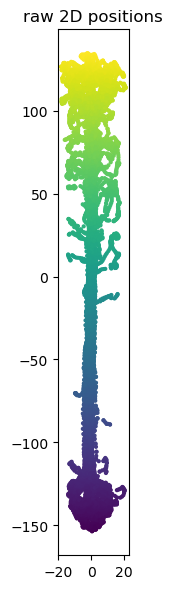

In [15]:
import numpy as np
import matplotlib.pyplot as plt

xy = cov_df[["x_raw", "y_raw"]].to_numpy()
xy_center = xy - xy.mean(axis=0, keepdims=True)

# principal direction of the track
_, _, vh = np.linalg.svd(xy_center, full_matrices=False)
v1 = vh[0]
theta = np.arctan2(v1[1], v1[0])

# rotate so the principal axis points vertically
phi = np.pi / 2 - theta
R = np.array([
    [np.cos(phi), -np.sin(phi)],
    [np.sin(phi),  np.cos(phi)]
])

xy_rot = xy_center @ R.T
xy_rot[:, 1] *= -1

fig, ax = plt.subplots(figsize=(4, 6))
ax.scatter(xy_rot[:, 0], xy_rot[:, 1], c=cov_df["pos_smooth"], s=4)
ax.set_title("raw 2D positions")
ax.set_aspect("equal")
plt.tight_layout()

from pathlib import Path
OUT = Path("figures_paper")
OUT.mkdir(parents=True, exist_ok=True)
fig.savefig(OUT / "hc3_raw_2d_positions_rotated.pdf", bbox_inches="tight")
print("saved:", OUT / "hc3_raw_2d_positions_rotated.pdf")

plt.show()

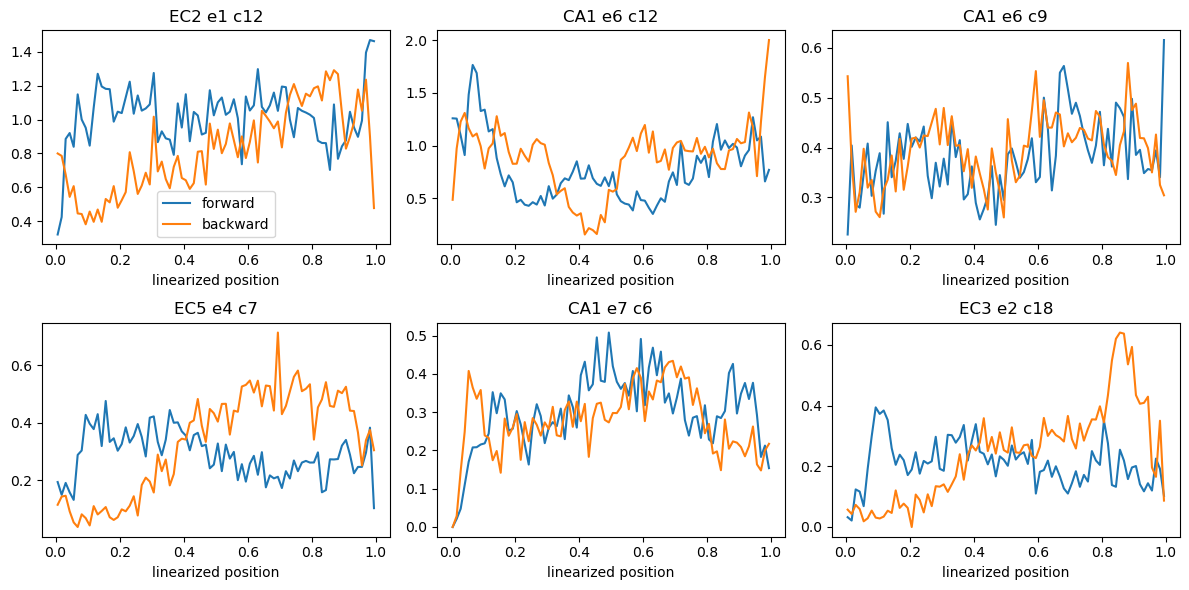

In [16]:
# Cell 9
# place fields split by direction
pos_edges = np.linspace(0, 1, POS_BINS + 1)
pos_centers = 0.5 * (pos_edges[:-1] + pos_edges[1:])

occ_f = np.histogram(cov_df.loc[cov_df["direction"] > 0, "pos_smooth"], bins=pos_edges)[0]
occ_b = np.histogram(cov_df.loc[cov_df["direction"] < 0, "pos_smooth"], bins=pos_edges)[0]

mean_counts = X.mean(axis=0)
top_units = np.argsort(mean_counts)[::-1][:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 6))
axes = axes.ravel()

for ax, j in zip(axes, top_units):
    sp_f = np.histogram(cov_df.loc[cov_df["direction"] > 0, "pos_smooth"], bins=pos_edges,
                        weights=X[cov_df["direction"] > 0, j])[0]
    sp_b = np.histogram(cov_df.loc[cov_df["direction"] < 0, "pos_smooth"], bins=pos_edges,
                        weights=X[cov_df["direction"] < 0, j])[0]

    rate_f = sp_f / np.maximum(occ_f, 1)
    rate_b = sp_b / np.maximum(occ_b, 1)

    u = unit_meta.iloc[j]
    ax.plot(pos_centers, rate_f, label="forward")
    ax.plot(pos_centers, rate_b, label="backward")
    ax.set_title(f"{u['region']} e{int(u['ele'])} c{int(u['clu'])}")
    ax.set_xlabel("linearized position")

axes[0].legend()
plt.tight_layout()
plt.show()

In [17]:
# Cell 10
summary = {
    "topdir": topdir,
    "session": session_name,
    "behavior": BEHAVIOR,
    "n_time_rows": int(X.shape[0]),
    "n_units": int(X.shape[1]),
    "regions_kept": unit_meta["region"].value_counts(dropna=False).sort_index().to_dict(),
    "core_covariates": ["pos_smooth", "direction"],
    "optional_covariates": ["time_norm", "x_norm", "y_norm", "x_raw", "y_raw"],
}
print(summary)

{'topdir': 'ec013.40', 'session': 'ec013.719', 'behavior': 'linear', 'n_time_rows': 29239, 'n_units': 62, 'regions_kept': {'CA1': 37, 'EC2': 9, 'EC3': 7, 'EC5': 9}, 'core_covariates': ['pos_smooth', 'direction'], 'optional_covariates': ['time_norm', 'x_norm', 'y_norm', 'x_raw', 'y_raw']}


In [18]:
# save processed dataset
import pickle
from pathlib import Path

OUT = Path("./hc-3-linear/processed")
OUT.mkdir(parents=True, exist_ok=True)

bundle = {
    "X": X,
    "cov_df": cov_df,
    "unit_meta": unit_meta,
    "topdir": topdir,
    "session_name": session_name,
    "behavior": BEHAVIOR,
    "summary": {
        "n_samples": int(X.shape[0]),
        "n_neurons": int(X.shape[1]),
        "core_covariates": ["pos_smooth", "direction"],
        "optional_covariates": ["time_norm", "x_norm", "y_norm", "x_raw", "y_raw"],
        "raw_2d_position_columns": ["x_raw", "y_raw"],
        "normalized_2d_position_columns": ["x_norm", "y_norm"],
    },
}

with open(OUT / "linear_rowwise.pkl", "wb") as f:
    pickle.dump(bundle, f)

print("saved:", OUT / "linear_rowwise.pkl")
print("covariates:", list(cov_df.columns))

saved: hc-3-linear/processed/linear_rowwise.pkl
covariates: ['time', 'time_norm', 'pos_smooth', 'direction', 'turning', 'x_raw', 'y_raw', 'x_norm', 'y_norm', 'direction01']
